# 01_config_constant_isotropic

- Constant isotropic covariance: Cov = lambda I_d. Baseline for numerical sanity.
- Config: `configs/config_constant_isotropic.yaml`
- Workflow: simulate -> realized covariance spectrum -> MP inverse -> recovery metrics.


In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (
        p
        for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'mpdiff').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root (expected pyproject.toml and src/mpdiff).')
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from mpdiff.config.loader import load_config
from mpdiff.experiments.run_end_to_end import run_end_to_end

config_path = PROJECT_ROOT / 'configs/config_constant_isotropic.yaml'
cfg = load_config(config_path)
out_dir = Path(cfg.global_settings.output_dir)
out_dir


PosixPath('outputs/config_constant_isotropic')

In [7]:
summary = run_end_to_end(config_path)
summary


2026-04-09 08:48:17,554 | INFO | mpdiff.experiments.run_full_pipeline | build_schedule completed in 0.010s
2026-04-09 08:48:17,597 | INFO | mpdiff.experiments.run_full_pipeline | Simulated diffusion: d=80, steps=4000, horizon=1.000000
2026-04-09 08:48:17,598 | INFO | mpdiff.experiments.run_full_pipeline | simulation completed in 0.037s
2026-04-09 08:48:17,600 | INFO | mpdiff.experiments.run_full_pipeline | compute_increments completed in 0.001s
2026-04-09 08:48:17,602 | INFO | mpdiff.experiments.run_full_pipeline | realized_covariance completed in 0.002s
2026-04-09 08:48:17,604 | INFO | mpdiff.experiments.run_full_pipeline | eigendecomposition completed in 0.001s
2026-04-09 08:48:17,605 | INFO | mpdiff.experiments.run_full_pipeline | empirical_density_estimation completed in 0.001s
2026-04-09 08:49:14,155 | INFO | mpdiff.experiments.run_full_pipeline | mp_inverse completed in 56.549s
2026-04-09 08:49:14,337 | INFO | mpdiff.experiments.run_full_pipeline | reference_population completed 

{'method': 'optimization',
 'aspect_ratio': 0.02,
 'reference_population_mean': 1.2000000001000009,
 'estimated_population_mean': 1.2059485436298816,
 'population_wasserstein_1': 0.013276107611710695,
 'reconstruction_l2': 0.07728458612671862,
 'output_dir': 'outputs/config_constant_isotropic'}

In [8]:
summary_csv = out_dir / 'full_pipeline_method_summary.csv'
meta_json = out_dir / 'full_pipeline_metadata.json'
report_txt = out_dir / 'full_pipeline_report.txt'

df = pd.read_csv(summary_csv)
display(df)

meta = json.loads(meta_json.read_text())
print('timers (seconds):')
for k, v in meta['timers_seconds'].items():
    print(f'  {k}: {v:.4f}')

print('\nreport preview:')
print(report_txt.read_text()[:1600])


,method,estimated_population_mean,population_l1,population_l2,population_wasserstein_1,population_support_min_diff,population_support_max_diff,population_moment1_abs_error,population_moment2_abs_error,population_moment3_abs_error,reconstruction_l1,reconstruction_l2,reconstruction_wasserstein_1
0,optimization,1.205949,0.137387,0.194898,0.013276,0.108216,0.117234,0.005949,0.017830,0.038713,0.059818,0.077285,0.003659
1,moment_based,1.204565,0.257849,0.383730,0.021916,0.090180,0.108216,0.004565,0.016591,0.040237,0.101039,0.123082,0.007379
2,fixed_point,1.203554,0.342907,0.494980,0.031089,0.198397,0.171343,0.003554,0.017128,0.046328,0.049019,0.057624,0.006230


timers (seconds):
  build_schedule: 0.0104
  compute_increments: 0.0014
  eigendecomposition: 0.0011
  empirical_density_estimation: 0.0005
  mp_inverse: 56.5490
  realized_covariance: 0.0016
  reference_population: 0.1813
  simulation: 0.0372

report preview:
mpdiff full pipeline report

config_path: /Users/gregoire.szymanski/Documents/random-matrices/configs/config_constant_isotropic.yaml
aspect_ratio_c: 0.02
realized_covariance_normalization: total_time
primary_method: optimization

method summary (sorted by population_wasserstein_1):
      method  estimated_population_mean  population_l1  population_l2  population_wasserstein_1  population_support_min_diff  population_support_max_diff  population_moment1_abs_error  population_moment2_abs_error  population_moment3_abs_error  reconstruction_l1  reconstruction_l2  reconstruction_wasserstein_1
optimization                   1.205949       0.137387       0.194898                  0.013276                     0.108216                    

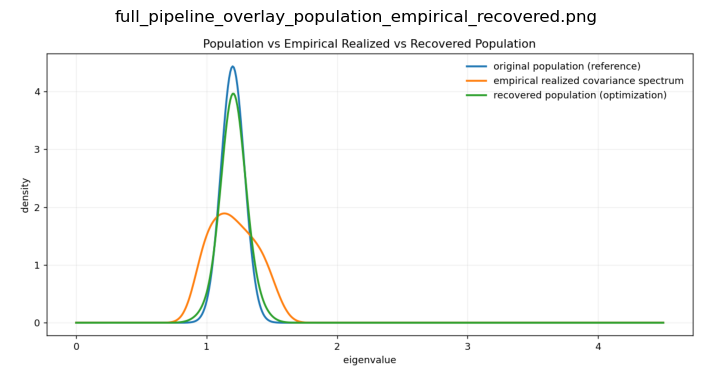

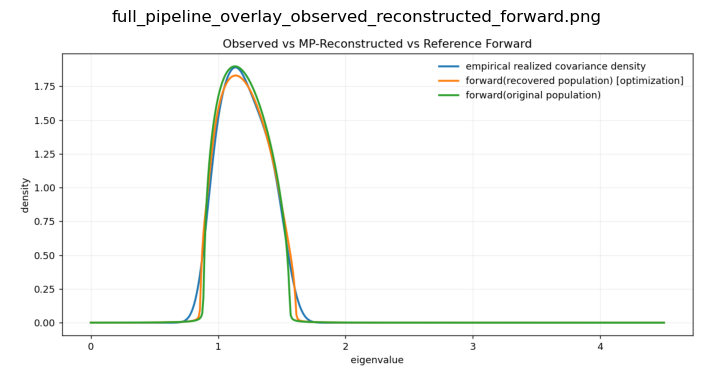

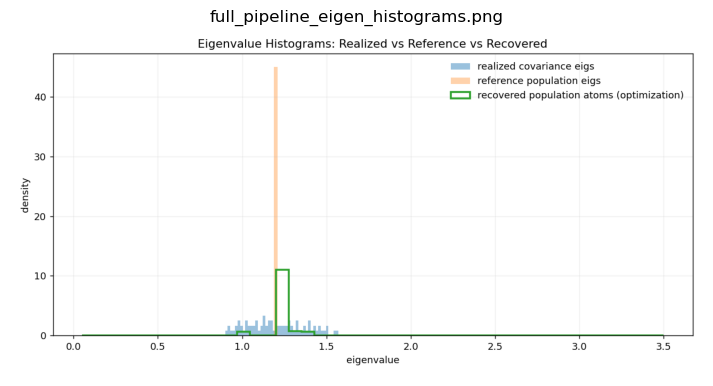

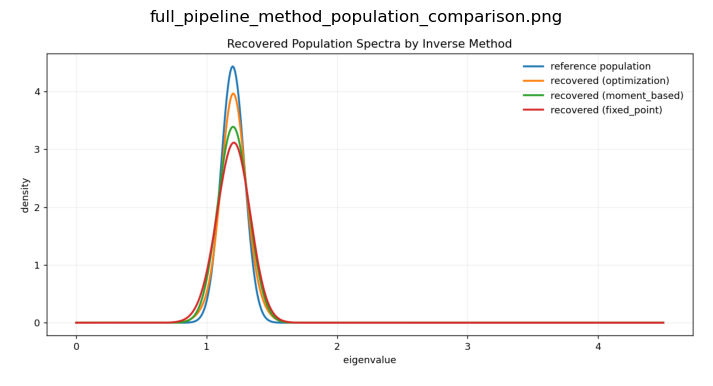

In [9]:
fig_paths = [
    out_dir / 'full_pipeline_overlay_population_empirical_recovered.png',
    out_dir / 'full_pipeline_overlay_observed_reconstructed_forward.png',
    out_dir / 'full_pipeline_eigen_histograms.png',
    out_dir / 'full_pipeline_method_population_comparison.png',
]

for p in fig_paths:
    if p.exists():
        img = mpimg.imread(p)
        plt.figure(figsize=(10, 4.5))
        plt.imshow(img)
        plt.title(p.name)
        plt.axis('off')
        plt.show()


## Interpretation Checklist

- Compare `population_wasserstein_1` and `reconstruction_l2` jointly.
- Inspect whether best method is stable across nearby config choices.
- For piecewise models, remember reference law is based on integrated covariance over time.
